In [1]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

RESULTS = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8")
IMPACT_OR_DIR = RESULTS / "impact_or"
CELLOT_DIR = RESULTS / "cellot"

_cellot_data = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad")
_repo_data = RESULTS / "data.h5ad"
DATA_PATH = str(_cellot_data if _cellot_data.exists() else _repo_data)

HOLDOUT = "CL:0000625"
CT_COL = "cell_type_ontology_term_id"
SOURCE, TARGET = "mouse", "human"


def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)


print(f"Data path: {DATA_PATH}")
print("Setup complete.")

Data path: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad
Setup complete.


In [2]:
full_data = anndata.read_h5ad(DATA_PATH)
print(f"Full dataset: {full_data.shape}")
print(f"Obs columns: {list(full_data.obs.columns)}")
print(f"\nCell types:")
for ct_id, n in full_data.obs[CT_COL].value_counts().items():
    label = ""
    if 'cell_type' in full_data.obs.columns:
        match = full_data.obs.loc[full_data.obs[CT_COL] == ct_id, 'cell_type']
        if len(match) > 0:
            label = f" ({match.iloc[0]})"
    print(f"  {ct_id}{label}: {n} cells")

ref = full_data.copy()
ref.X = to_dense(ref.X).astype(np.float32)

print(f"\nComputing PCA (n_comps=30) ...")
sc.pp.pca(ref, n_comps=30)

print("Computing neighbors (n_neighbors=15, n_pcs=30) ...")
sc.pp.neighbors(ref, n_pcs=30, n_neighbors=15)

print("Computing UMAP (min_dist=0.3, random_state=42) ...")
sc.tl.umap(ref, min_dist=0.3, random_state=42)

print(f"\nReference UMAP done: {ref.obsm['X_umap'].shape}")

Full dataset: (12836, 1000)
Obs columns: ['condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id']

Cell types:
  CL:0008001 (hematopoietic precursor cell): 1584 cells
  CL:0000037 (hematopoietic stem cell): 1442 cells
  CL:0002393 (intermediate monocyte): 1008 cells
  CL:0000623 (natural killer cell): 912 cells
  CL:0000893 (thymocyte): 910 cells
  CL:0000875 (non-classical monocyte): 852 cells
  CL:1000320 (large intestine goblet cell): 760 cells
  CL:0002063 (pulmonary alveolar type 2 cell): 584 cells
  CL:0002543 (vein endothelial cell): 574 cells
  CL:0002548 (fibroblast of cardiac tissue): 484 cells
  CL:0002598 (bronchial smooth muscle cell): 440 cells
  CL:0000786 (plasma cell): 410 cells
  CL:0000236 (B cell): 406 cells
  CL:0000115 (endothelial cell): 406 cells
  CL:0000625 (CD8-positive, alpha-beta T cell): 390 cells
  CL:0000767 (basophil): 286 cells
  CL:0000084 (T cell): 204 cells
  CL:0000235 (macrophage): 204 cells
  CL:00

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing UMAP (min_dist=0.3, random_state=42) ...

Reference UMAP done: (12836, 2)


In [3]:
ref

AnnData object with n_obs × n_vars = 12836 × 1000
    obs: 'condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [4]:
from sklearn.neighbors import NearestNeighbors

predictions = {}

imp_path = IMPACT_OR_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if imp_path.exists():
    _imp = anndata.read_h5ad(str(imp_path))
    _imp.var_names = ref.var_names.copy()
    predictions['IMPACT-OR'] = _imp
    print(f"IMPACT-OR: {_imp.shape}")

cot_path = CELLOT_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if cot_path.exists():
    _cot = anndata.read_h5ad(str(cot_path))
    _cot.var_names = ref.var_names.copy()
    predictions['CellOT'] = _cot
    print(f"CellOT: {_cot.shape}")


def project_onto_ref_umap(pred_X, ref_adata, n_neighbors=10):
    """Project cells onto reference UMAP via kNN weighted average in PCA space."""
    pcs = ref_adata.varm['PCs']
    ref_pca = ref_adata.obsm['X_pca']
    ref_umap = ref_adata.obsm['X_umap']
    
    pred_centered = pred_X - ref_adata.X.mean(axis=0)
    pred_pca = pred_centered @ pcs
    
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(ref_pca)
    dists, idxs = nn.kneighbors(pred_pca)
    
    weights = 1.0 / (dists + 1e-8)
    weights = weights / weights.sum(axis=1, keepdims=True)
    pred_umap = np.array([
        (weights[i, :, None] * ref_umap[idxs[i]]).sum(axis=0)
        for i in range(len(pred_pca))
    ])
    return pred_umap


for name, pred_adata in predictions.items():
    pred_X = to_dense(pred_adata.X).astype(np.float32)
    pred_umap = project_onto_ref_umap(pred_X, ref)
    predictions[name].obsm['X_umap'] = pred_umap
    print(f"{name}: projected {pred_adata.n_obs} cells")

IMPACT-OR: (195, 1000)
CellOT: (6223, 1000)
IMPACT-OR: projected 195 cells
CellOT: projected 6223 cells


In [21]:
ref.obs['CD8 T cell'] = ref.obs['cell_type']=='CD8-positive, alpha-beta T cell'

In [27]:
cd8_species = []
for idx, cell in ref.obs.iterrows():
    if cell['cell_type'] == 'CD8-positive, alpha-beta T cell':
        if cell['condition'] == 'mouse':
            cd8_species += ['mouse CD8']
        else:
            cd8_species += ['human CD8']
    else:
        cd8_species += ['other']

In [30]:
pd.Series(cd8_species).value_counts()

other        12446
mouse CD8      195
human CD8      195
Name: count, dtype: int64

In [31]:
ref.obs['CD8 species'] = cd8_species

In [46]:
ref.obs['CD8 T cell'].value_counts()

CD8 T cell
False    12446
True       390
Name: count, dtype: int64

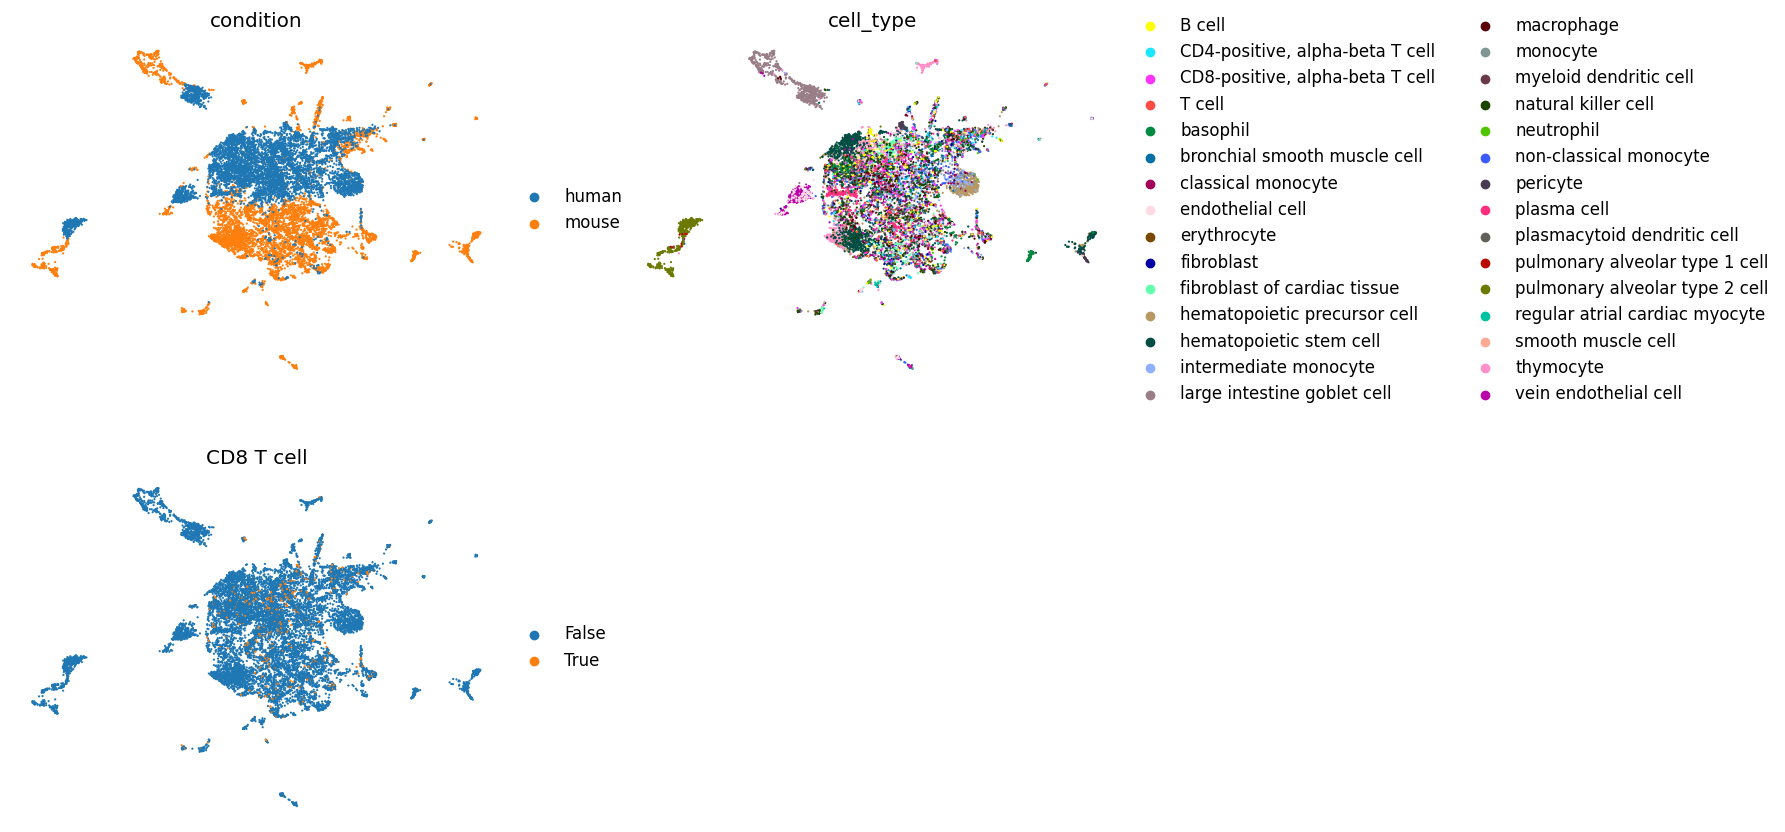

<Figure size 640x480 with 0 Axes>

In [22]:
sc.pl.umap(ref, color=['condition', 'cell_type', a], frameon=False, s=10,
           ncols=2)
plt.tight_layout()
plt.show()

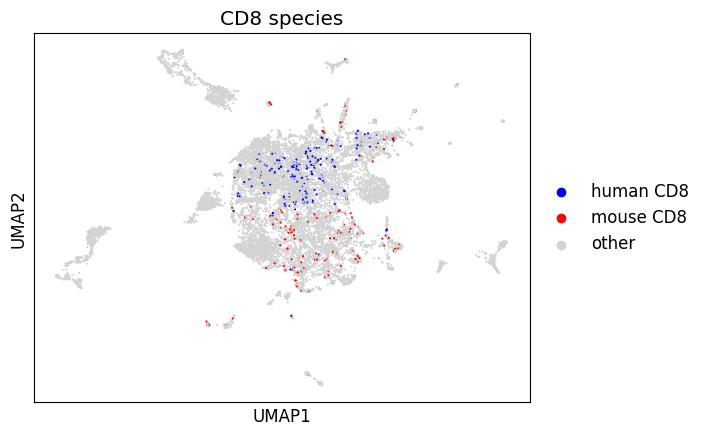

In [64]:
sc.pl.umap(ref, 
           color=['CD8 species'],
           palette={"other": 'lightgray', "mouse CD8": 'red',"human CD8": 'blue' },
           sort_order=True)

In [35]:
ref[predictions['IMPACT-OR'].obs.index].obs['cell_type'].value_counts()

cell_type
CD8-positive, alpha-beta T cell    195
Name: count, dtype: int64

In [37]:
ref[predictions['IMPACT-OR'].obs.index].obs['condition'].value_counts()

condition
mouse    195
Name: count, dtype: int64

In [50]:
cd8_only = ref[ref.obs['CD8 T cell']==True] 

In [51]:
cd8_only

View of AnnData object with n_obs × n_vars = 390 × 1000
    obs: 'condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id', 'CD8 T cell', 'CD8 species'
    uns: 'pca', 'neighbors', 'umap', 'condition_colors', 'cell_type_colors', 'CD8 T cell_colors', 'CD8 species_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

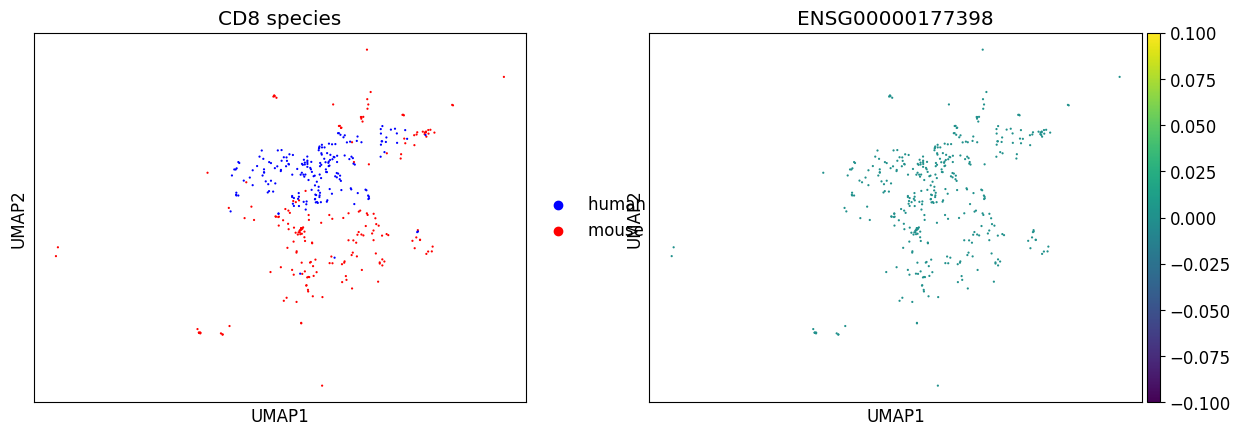

In [62]:
sc.pl.umap(cd8_only, 
           color=['CD8 species','ENSG00000177398'], 
           palette={"other": 'lightgray', "mouse CD8": 'red',"human CD8": 'blue' },
           sort_order=True,
           size=10)

In [61]:
'ENSG00000126353' in ref.var

False

In [15]:

ref.obs.loc['CGTCACTCAGACAAAT-1-31-0-0']

condition                                               mouse
cell_type_ontology_term_id                         CL:0000625
cell_type                     CD8-positive, alpha-beta T cell
tissue_ontology_term_id                        UBERON:0002048
tissue                                                   lung
donor_id                                              18-M-52
Name: CGTCACTCAGACAAAT-1-31-0-0, dtype: object

In [71]:
ref.var[:10].index.tolist()

['ENSG00000114374',
 'ENSG00000154646',
 'ENSG00000184221',
 'ENSG00000177398',
 'ENSG00000183640',
 'ENSG00000274749',
 'ENSG00000182591',
 'ENSG00000204899',
 'ENSG00000197683',
 'ENSG00000206107']

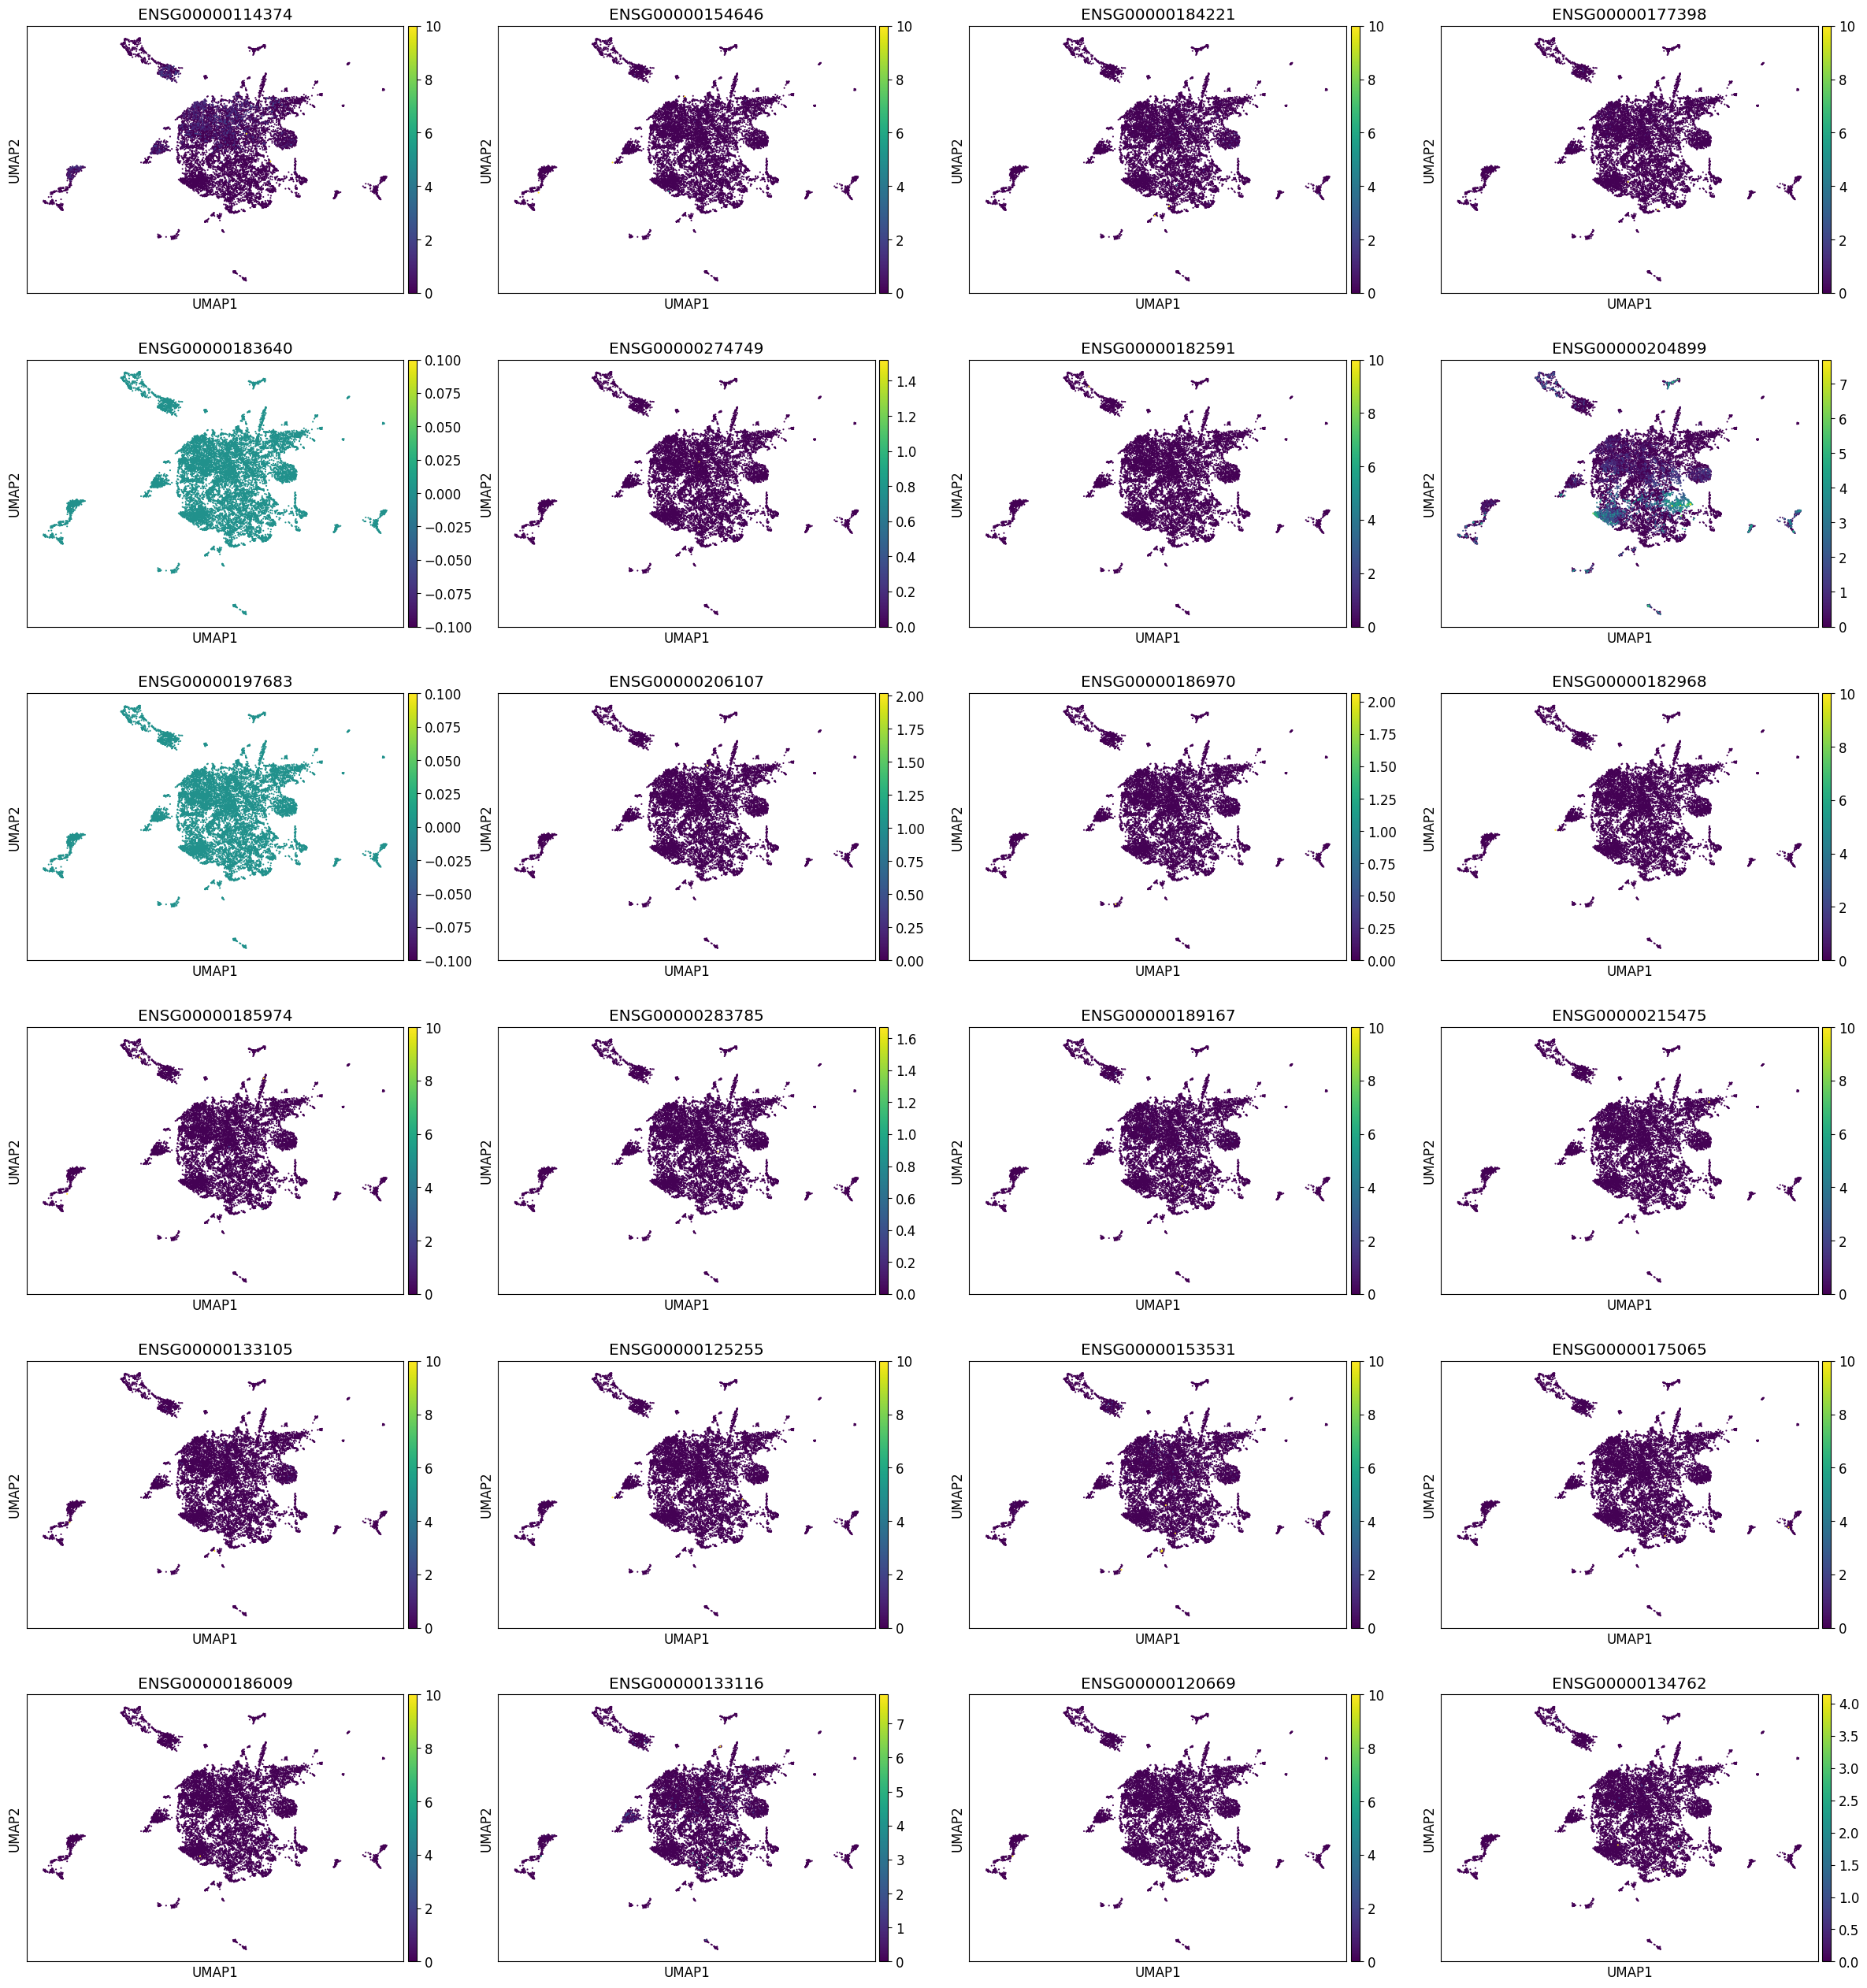

In [73]:
sc.pl.umap(ref, 
           color=ref.var[:24].index.tolist(),
           palette={"other": 'lightgray', "mouse CD8": 'red',"human CD8": 'blue' },
           sort_order=True)